In [96]:
from qiskit import __version__
print(__version__)

2.4.1


# Importing Packages

In [97]:
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit.quantum_info import Statevector, state_fidelity, DensityMatrix, partial_trace
from qiskit_aer import AerSimulator
from qiskit_aer.library import SaveDensityMatrix, SaveStatevector
import numpy as np
from qiskit_aer.noise import NoiseModel, depolarizing_error, ReadoutError
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter, NullFormatter
import matplotlib.ticker as mticker
from matplotlib.patches import Rectangle
from matplotlib.gridspec import GridSpec
from multiprocessing import Pool
import time

# Graphing Settings

In [98]:
# --- APS-style global settings ---
mpl.rcParams.update({
    'text.usetex': True,
    'font.family': 'serif',
    'font.size': 8,
    'axes.labelsize': 9,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    'legend.fontsize': 8,
    'lines.linewidth': 1.2,
    'figure.dpi': 150,
})

# Defining Global Variables

In [99]:
h1 = 0.79605
h2 = -0.18092
h3 = -0.32096
t = np.pi/(8*h1)
alpha0 = 0
alpha1 = 0
kmax = 12 

# Functions

In [100]:
def state_prep(qc):
    qc.h(0)
    qc.x(1)
    qc.ry(alpha0, 1)
    qc.rz(alpha1, 1)

def control_uk(qc):
    qc.rz(h1*t, 1)
    qc.cx(0,1)
    qc.rz(-h1*t, 1)
    qc.cx(0,1)
    qc.h(1)
    qc.rz(h2*t, 1)
    qc.cx(0,1)
    qc.rz(-h2*t, 1)
    qc.cx(0,1)
    qc.h(1)
    
def qpe(qc, k, beta):
    state_prep(qc)
    for _ in range(k):
        control_uk(qc)
    qc.rz(beta, 0)
    qc.h(0)
    qc.measure([0], [0])
    
def calculate_Q(k_list, beta_list, m_list, tilde_phi, eps=1e-15):
    k_array = np.asarray(k_list, dtype=float)
    beta_array = np.asarray(beta_list, dtype=float)
    m_array = np.asarray(m_list, dtype=float)

    probs = (1 + np.cos(k_array * tilde_phi + beta_array - m_array * np.pi)) / 2
    probs = np.clip(probs, eps, 1.0)

    return np.sum(np.log(probs))

def estimate_phase(k_list, beta_list, m_list):
    Q_list = np.array([
        calculate_Q(k_list, beta_list, m_list, tilde_phi)
        for tilde_phi in tilde_phi_list
    ])

    max_idx = np.argmax(Q_list)
    return tilde_phi_list[max_idx]

# Returns [-pi, pi)
def circular_mean0(phi_list):
    phi_array = np.asarray(phi_list, dtype=float)

    mean_complex = np.mean(np.exp(1j * phi_array))
    phi_avg = np.angle(mean_complex)

    R_bar = np.abs(mean_complex)

    if np.isclose(R_bar, 0.0):
        holevo_variance = np.inf
        holevo_std = np.inf
    else:
        holevo_variance = 1 / (R_bar**2) - 1
        holevo_std = np.sqrt(holevo_variance)

    return phi_avg, holevo_variance, holevo_std

# Returns [0, 2*pi)
def circular_mean1(phi_list):
    phi_avg, holevo_variance, holevo_std = circular_mean0(phi_list)

    phi_avg = phi_avg % (2 * np.pi)

    return phi_avg, holevo_variance, holevo_std

# QPE Algorithm

In [91]:
rng = np.random.default_rng(seed=time.time_ns())

N_s = 2186
R = 1_000

original_k_list = rng.integers(1, kmax + 1, size=N_s)
original_beta_list = rng.choice([0.0, np.pi / 2], size=N_s)

backend = AerSimulator()

original_m_list = []

for i in range(N_s):
    qc = QuantumCircuit(2, 1)
    qpe(qc, original_k_list[i], original_beta_list[i])

    job = backend.run(qc, shots=1)
    result = job.result()
    counts = result.get_counts()

    measured_bit = int(next(iter(counts.keys())))
    original_m_list.append(measured_bit)

original_m_list = np.asarray(original_m_list)

phi_list = []
Q_list = []
tilde_phi_list = np.linspace(0, 2 * np.pi, 20_000, endpoint=False)
for _ in range(R):
    indices = rng.choice(N_s, size=N_s, replace=True)

    k_list = original_k_list[indices]
    beta_list = original_beta_list[indices]
    m_list = original_m_list[indices]

    phi_est = estimate_phase(k_list, beta_list, m_list)
    phi_list.append(phi_est)

estimated_phase, holevo_variance, holevo_std = circular_mean0(phi_list)

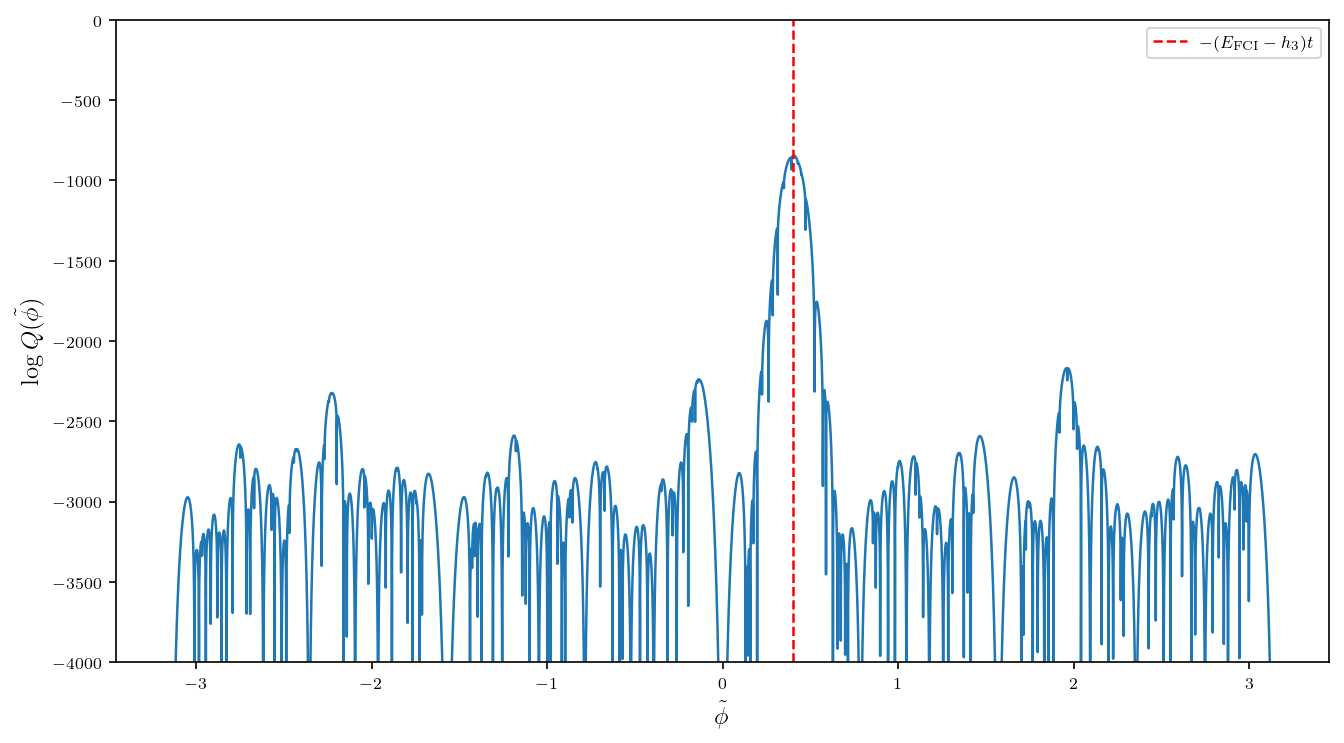

In [112]:
logQ_list = np.array([
    calculate_Q(original_k_list, original_beta_list, original_m_list, tilde_phi)
    for tilde_phi in tilde_phi_list
])

# Convert phase axis from [0, 2pi) to [-pi, pi)
tilde_phi_signed = (tilde_phi_list + np.pi) % (2 * np.pi) - np.pi

# Sort so the line plot is continuous
sort_idx = np.argsort(tilde_phi_signed)

plt.figure(figsize=(9, 5))
plt.plot(tilde_phi_signed[sort_idx], logQ_list[sort_idx])


E_FCI = -1.13731
phi_target = -(E_FCI - h3) * t
phi_target_signed = (phi_target + np.pi) % (2 * np.pi) - np.pi
plt.axvline(phi_target_signed, linestyle="--", label=r"$-(E_{\rm FCI}-h_3)t$", color='red')

plt.xlabel(r"$\tilde{\phi}$", fontsize=12)
plt.ylabel(r"$\log Q(\tilde{\phi})$", fontsize=12)
plt.ylim(-4_000, 0)
plt.legend()
plt.tight_layout()
plt.show()

In [109]:

# estimated_phase is already in [-pi, pi)
E_est = h3 - estimated_phase / t

# Holevo phase uncertainty -> energy uncertainty
sigma_phi = holevo_std
sigma_E = sigma_phi / t

print(f"Estimated phase = {estimated_phase:.8f} rad")
print(f"Holevo std phase uncertainty = {sigma_phi:.8f} rad")
print(f"Estimated energy = {E_est:.8f} Ha")
print(f"Energy uncertainty = {sigma_E:.8f} Ha")
print(f"|E - E_FCI| = {np.abs(E_est - E_FCI):.8f} Ha")

Estimated phase = 0.40501130 rad
Holevo std phase uncertainty = 0.00295334 rad
Estimated energy = -1.14196840 Ha
Energy uncertainty = 0.00598679 Ha
|E - E_FCI| = 0.00465840 Ha


# Saving Data

In [ ]:
np.savez(
    "ideal.npz",
    N_s=N_s,
    estimated_phase=estimated_phase, 
    holevo_variance=holevo_variance, 
    holevo_std=holevo_std,
    original_k_list=original_k_list,
    original_beta_list=original_beta_list,
    original_m_list=original_m_list,
    tilde_phi_list=tilde_phi_list
)

# Loading Data

In [ ]:
data = np.load("ideal.npz")

N_s = data["N_s"]
estimated_phase = data["estimated_phase"]
holevo_variance = data["holevo_variance"]
holevo_std = data["holevo_std"]
original_k_list = data["original_k_list"]
original_beta_list = data["original_beta_list"]
original_m_list = data["original_m_list"]
tilde_phi_list = data["tilde_phi_list"]

# Saving Data for Final Plot

In [113]:
np.savez(
    "final_plot_ideal.npz",
    x_axis=tilde_phi_signed[sort_idx],
    y_axis=logQ_list[sort_idx],
    estimated_phase=estimated_phase,
    sigma_phi=sigma_phi,
    E_est=E_est,
    sigma_E=sigma_E
)